In [38]:
import pandas as pd # data loading, cleaning, time-series handling
import numpy as np # numerical operations

# Plot trends, seasonality, predictions vs actual
import matplotlib.pyplot as plt
import seaborn as sns

# time series handling
from datetime import datetime

# preprcessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

In [39]:
# MODELS
from sklearn.linear_model import LinearRegression

#Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model Saving & Loading
import joblib



In [40]:
df = pd.read_csv(
    "../data/household_power_consumption.txt",
    sep=';',
    na_values=['?'],
    parse_dates={'Datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    low_memory=False
)

# na_values=['?'] → converts hidden missing values
# parse_dates → merges Date + Time into a real timestamp
# low_memory=False → avoids mixed dtype garbage

C:\Users\osumb\AppData\Local\Temp\ipykernel_19176\3203016810.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
C:\Users\osumb\AppData\Local\Temp\ipykernel_19176\3203016810.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
C:\Users\osumb\AppData\Local\Temp\ipykernel_19176\3203016810.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


In [41]:
df.head()

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [42]:
# viewing no of columns and rows
df.shape

(2075259, 8)

In [43]:
# data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Datetime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB


### Fix data types

In [45]:
# Force correct data types to numeric
cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

df[cols] = df[cols].apply(pd.to_numeric)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Datetime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB


### Handle Missing values

In [47]:
df.isnull().sum()

Datetime                     0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [48]:
# drop null values
df  = df.dropna()

In [49]:
df.isnull().sum()

Datetime                 0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [50]:
df.head()

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


### creating a date-time index

In [55]:
df.set_index('Datetime', inplace=True)

In [56]:
df.shape

(2049280, 7)

In [57]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2049280 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 125.1 MB


In [58]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


C:\Users\osumb\AppData\Local\Temp\ipykernel_19176\3860872642.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df.resample('H').mean()


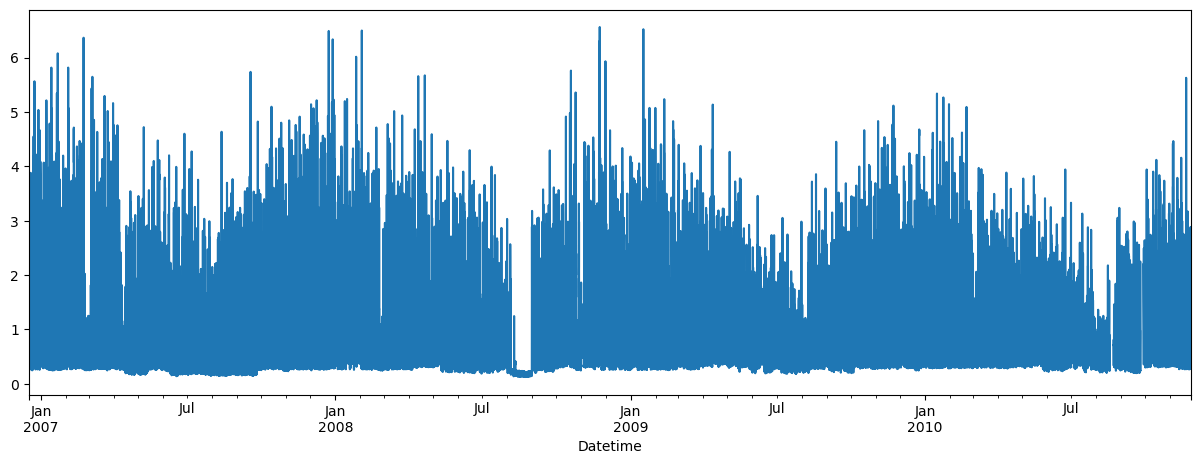

In [60]:
#trying to plot to see if it makes sense
df_resampled = df.resample('H').mean()

import matplotlib.pyplot as plt

df_resampled['Global_active_power'].plot(figsize=(15,5))
plt.show()

# Building Time-Based Features - where models get power

### Extract core time features

In [62]:
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['day_of_week'] = df.index.dayofweek  # 0 = Monday
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# hour - captures daily usage cycles (morning/evening spikes)
# day_of_week - weekday vs weekend behavior
# month - seasonal effects (weather, holidays)

In [63]:
df['lag_1'] = df['Global_active_power'].shift(1)
df['lag_60'] = df['Global_active_power'].shift(60)   # 1 hour before
df['lag_1440'] = df['Global_active_power'].shift(1440)  # 1 day before

In [64]:
df['rolling_mean_60'] = df['Global_active_power'].rolling(window=60).mean()
df['rolling_std_60'] = df['Global_active_power'].rolling(window=60).std()

### Undestanding seasonality

<Axes: xlabel='hour'>

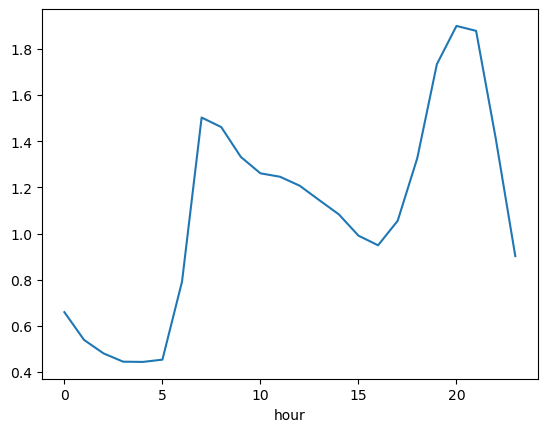

In [70]:
# hourly pattern
df.groupby('hour')['Global_active_power'].mean().plot()

<Axes: xlabel='day_of_week'>

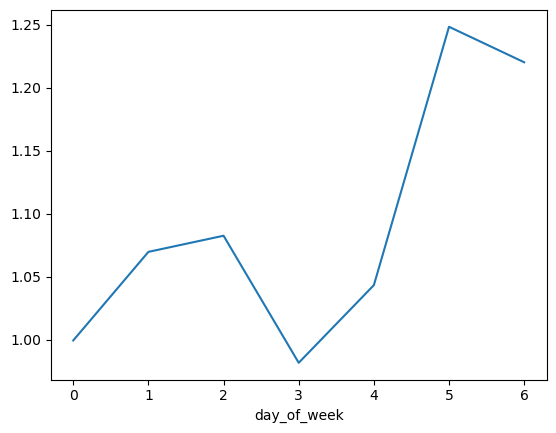

In [71]:
# weekly pattern
df.groupby('day_of_week')['Global_active_power'].mean().plot()

<Axes: xlabel='month'>

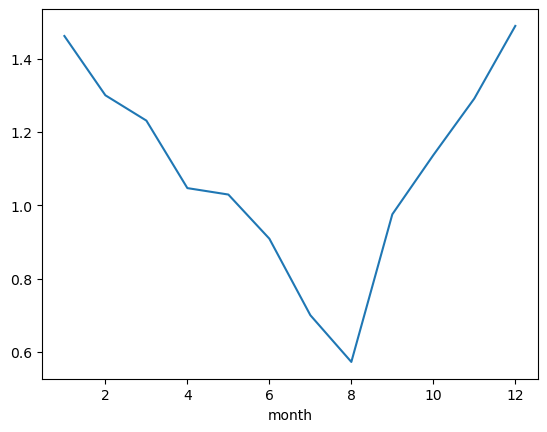

In [72]:
# Monthly pattern
df.groupby('month')['Global_active_power'].mean().plot()

# Resampling + Aggregation

In [75]:
# Convert to hourly - balanced
df_hourly = df.resample('H').mean()

C:\Users\osumb\AppData\Local\Temp\ipykernel_19176\3154391646.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


In [76]:
# Convert to daily - trend focused
df_daily = df.resample('D').mean()

# Modeling

In [77]:
# drop null values
df = df.dropna()

In [79]:
# Define the features and tagets
features = [
    'hour', 'day_of_week', 'month', 'is_weekend',
    'lag_1', 'lag_60', 'lag_1440',
    'rolling_mean_60', 'rolling_std_60'
]

X = df[features]
Y = df['Global_active_power']

In [80]:
# Train-test split
train_size = int(len(df) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [81]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50)
model.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
# Evaluate
from sklearn.metrics import mean_absolute_error

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print("MAE:", mae)

MAE: 0.09483623771148106
